## Acerca de la bibloteca de Scikit-Learn
 - Para poder entrenar un modelo de aprendizaje supervisado: NombreModelo.fit(X_train, Y_train)

 - para entrenar un modelo de aprendizaje no supervisado :
 NombreModelo.fit(X_train)

 - Para predecir utilizando un modelo ya entrenado: 
 NombreMOdelo.predict(X_test)

 - Dividir el conjunto de datos en un conjunto de entreamiento y conjunto de prueba: 
 X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.3,random_state = 123) 
 
 - para calcular una metrica de rendimiento(Precisión):
 metrics.accuracy_score(Y_test,Y_pred)

 - para validar de forma cruzada y hacer el ajuste de los hiperparametros al mismo tiempo 
 myGridCV = GridSearchCV(estimador,parameter_grid,cv=k)
 myGridCV.fit(X_train,Y_train)

## Preprocesamiento de datos para hacer un buen conjunto de datos de entrenamiento 

- Limpieza de los datos para su analisis: <br><br>   - procesamiento de valores ausentes <br>  1. Ignorar el Registro (fila) <br> 2. Insertar el valor que falta ya con su promedio o media global 

In [10]:
import pandas as pd
import numpy as np 
from sklearn.datasets import load_iris 
from sklearn.model_selection import train_test_split

iris=load_iris()    # cargamos el conjunto de datos de iris 
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)   # Creamos un data frame con los datos de iris
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [11]:
#procesamiento de Valores ausentes 
iris_df.columns
iris_df['sepal length (cm)'] # seleccionamos la columna 'sepal length (cm) '
np.mean(iris_df['sepal length (cm)']) # obtuvimos el promedio de la columns 'sepal length'

np.float64(5.843333333333334)

# Tratamiento de datos categoricos <br>
 - Escala categorica: permite distinguir los datos en diferentes categorias las cuales son nominal y ordinal <br> 
 - Escala continua: es una escala que divide los datos vinculados en intervalos y/o proporcion 

# Consideraciones del aprendizaje automatico 
1. Definir el problema y comprobar las mejores soluciones o planes alternativos 
2. comprovar si es posible definir como problemas __supervisados o no supervisados__
3. Definir que metodo se va a usar para __medir el rendimiento del modelo__
4. comprobar si el indice de rendimiento esta vinculado con los objetivos del equipo

## Problema de practica 
- defina el problema como especie de iris (supervisado) y suponga que el resultado es satisfactorio si el rendimiento predice una precision de clasificacion del 85% o superior 

# Entender los datos de iris 
- Nombre de los datos -> IRIS
- Numero de datos  -> 150 
- variables
1. longuitud de los sepalos
2. anchura del sepalo 
3. longitud del petalo 
4. anchura del petalo 
5. Especie de flores, clasificacion en setosa / versicolor / virginica   

In [21]:
import numpy as np
import seaborn as sns 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

data = load_iris() # cargamos el conjunto de datos de iris 
data.keys() 
iris = pd.DataFrame(data = data.data, columns = data.feature_names) # Creamos un data frame con los datos de iris
iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


* Nota __.describe__ nos muetra una breve descripcion del dataframe (promedio,desviacion estandar, min,max)

In [19]:
##Dividir el conjunto de datos en entrenamiento y prueba 
X_train,X_test,y_train,y_test = train_test_split(iris.iloc[:,:-1],iris.iloc[:,-1],test_size=0.33, random_state=42)
'''X es la caracteristica del conjunto de datos, e Y es el objetivo'''

## Analisis de correlacion para ver la relacion entre las caracteristicas 
iris.corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


## Nota
- la correlacion: nos indica la magnitud y direccion que puede existir entre dos variables 
https://www.youtube.com/watch?v=IBMrXyTR6CU

In [14]:
# Visualizacion de estadisticas basicas y de valores atipicos 
def boxplot_iris(feature_names, dataset):
    i = 1
    plt.figure(figsize=(11,9))
    for col in feature_names:
        plt.subplot(2,2,i)
        plt.axis('on')
        plt.tick_params(axis='both',left=True,
                        top = False,right = False,
                        bottom = True,labelleft = True,
                        labeltop = False, labelright = False,
                        labelbottom = False)
        dataset[col].hist()
        plt.title(col)
        i+=1
    plt.show()



## Graficacion de los datos de Iris

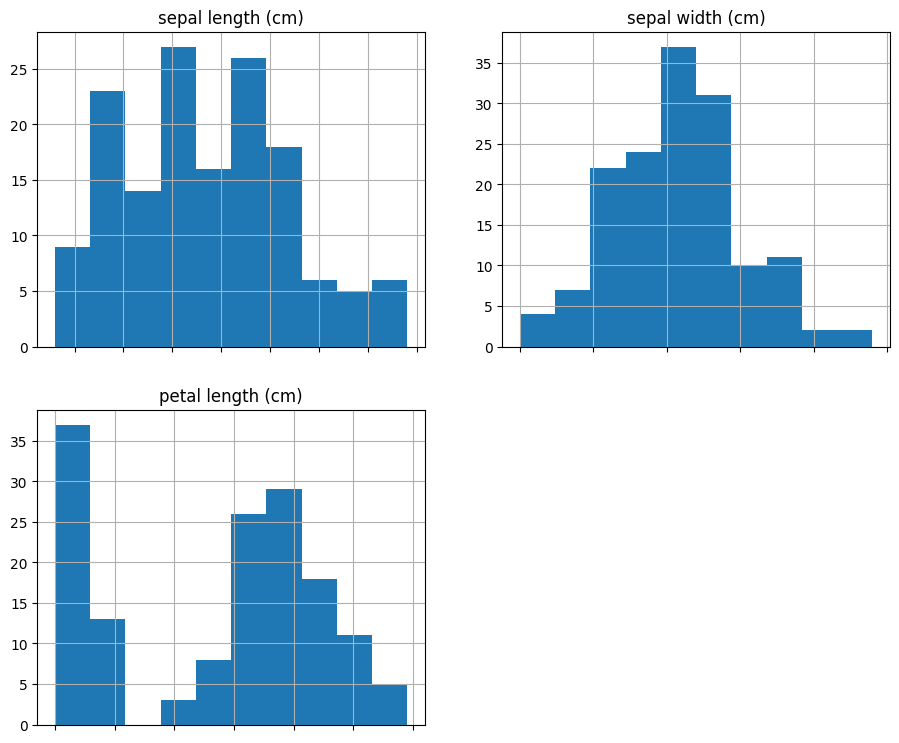

In [15]:
boxplot_iris(iris.columns[:-1],iris)

- Seleccion de Algoritmos

In [16]:
model = DecisionTreeClassifier(criterion='gini',splitter='best',max_depth=None,min_samples_split=2,
                            min_samples_leaf=1,min_weight_fraction_leaf=0.0,max_features=None,
                            random_state=42,max_leaf_nodes=None,min_impurity_decrease=0.0,
                            class_weight=None)


# Aprendizaje con modelos 
- se reliza el aprendizaje del modelo con los datos de entrenamiento para comprobar el rendimiento del modelo<br>

model.fit(X_train,y_train)  <br>

- Puntuacion 
en esta parte se evalua el rendimiento utilizando el conjunto de datos de prueba. esto hace referencia a la exatitud. Dado que el conjunto de datos(Iris) esta bien estructurado tiene una alta puntuacion <br>

model.score(X_test,y_test)

## Estrategia de genaralizacion de un modelo:
 la idea principal se basa en que un modelo no debe solo aprenderse los datos<br>
debe funcionar bien con datos nuevos que nunca ha visto<br>
<br>
Nota si se cuenta con pocos datos el modelo puede 
- aprenderse los datos de entrenamiento 
- tiende a fallar con datos nuevos <br>

Eso se llama sobreajuste (overfitting)<br>
<br>
Entonces la estrategia de generalizacion busca: Que el modelo funcione bien no solo con los datos de entrenamiento, sino que tambien con datos nuevos 

## Conjunto de validacion 
cuando entrenamos un modelo normalmente dividimos los datos en 3 partes 
1. Entranamiento- para que el modelo aprenda 
2. Validacion- para probar mientras lo entrenamos 
3. Prueba(Test)- para evaluar el rendimiento final 
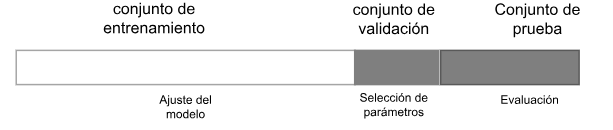

## Validacion Cruzada 
es una forma mas intelgente de evaluar el modelo ya que en lugar de dividir los datos solo una vez en entrenamiento y prueba, lo que se hace es dividirlo varias veces 
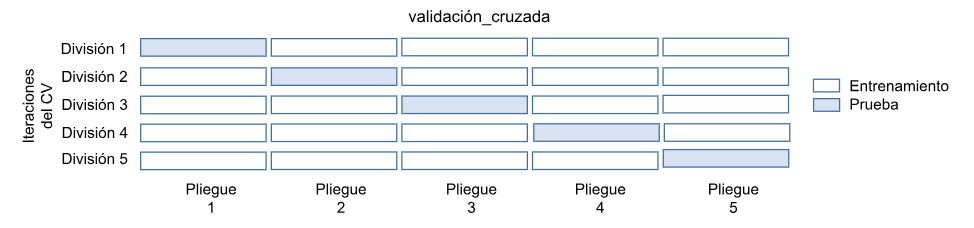 

## Estratificacion 
es una forma de dividir los datos manteninedo la misma proporcion de clases en cada division, en otras palabras se asegura de que en cada division haya la misma proporcion de los datos  <br>
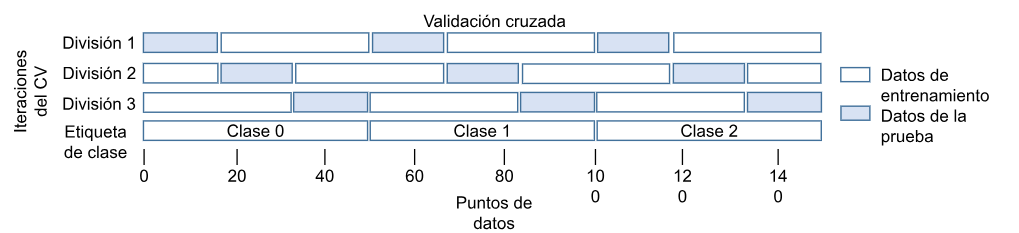

## Estrategia de optimizacion del modelo 
- Hiperparametros: los hiperparametros hacen referencia a los parametros que deben ser asignados directamente por una persona, ya que no pueden ser encontrados por la maquina 


- Busqueda de Hiperparametros mediante GridSearchCV 
es un metodo que prueba muchas combinaciones de parametros de tu modelo para encontrar cual funciona mejor <br>
<br>
¿Que hace GridSearchCV?
1. indicas que valores quieres probar 
2. El se encarga de probar todas las combinaciones posibles 
3. usa validacion cruzada para evaluar cada combinacion 
4. te devuelve la mejor 

## Criterios de evaluacion del modelo 
Utilizando las pruebas X_test, y_test de retancion para la evaluacion final del modelo, para una evaluacion precisa,es importante conocer diferentes tipos de criterios de evaluacion 

<br>TP(verdadero positivo),TN(verdadero negativo),FP(falsos positivos),FN(falsos negativos)<br>

- Matriz de confucion: es como un reporte que te dice,aqui acertate, aqui te equivocaste y de que tipo fue tu error. Siempre se toma en cuenta la diagonal principal de la matriz
ya que hay estan los aciertos del modelo 

- Exactitud: (Accuracy) cuantas veces predijo correctamente el modelo <br>
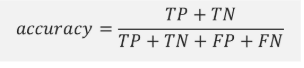

- Precisión: Tomamos mas en cuenta los FP (captura el error causado por los FP)<br>
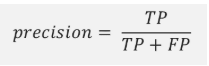

- recall(tasa de recuperacion): Tomamos mas en cuenta los FN  (captura el error causado por los FN)<br>
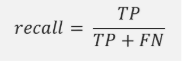

- fall-out: mide de todos los casos que eran negativos, ¿Cuantos clasificastes incorectamente como positivos?<br>
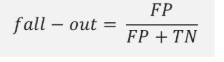

- f1-score: combina las metricas de recall y precision en una sola usando una media entre estas<br> 
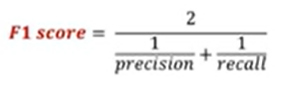

## Curva ROC 
la curva roc muestra que tan bien tu modelo separa las clases 
- ¿Que compara?
la curva ROC grafica <br>
Eje Y -> Recall(TPR): que tantos positivos detectas<br> 
Eje X -> Fall-Out(FPR): cuantos negativo clasificaste mal 


## Tipos de error 
- Error de sesgo (error de subajuste):
es el error que se produce cuando un modelo es demasiado simple y no logra capturar correctamente la relacion real entre las variables, de forma mas sencilla. Es la diferencia entre lo que el modelo predice en promedio y el valor real. <br>
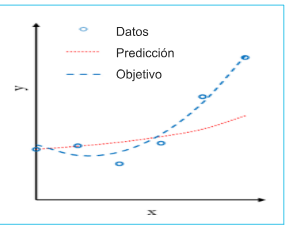

- Error de varianza (error de sobreajuste): es el error que aprece cuando un modelo es demasiado complejo y se ajusta demasiado a los datos de entrenamiento. Hay que tomar en cuenta que una altaa varianza = modelo inestable ante pequeñas variaciones en los datos <br> 
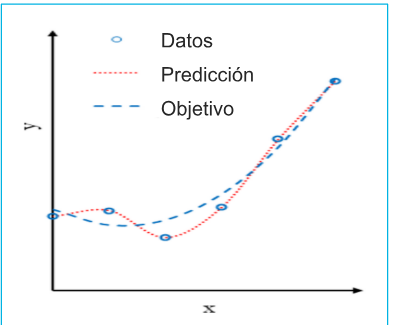


- Error total: es el error esperado que comete un modelo al predecir sobre datos nuevos, se calcula de la sig manera 

    __Error total = Error de sesgo + Error de varianza__ 
    <br>
    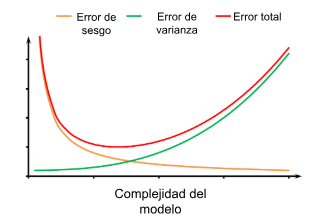


# Minimizar errores 
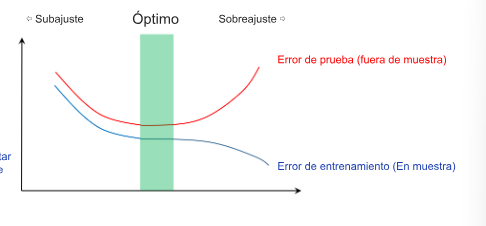

- Ejes de la garfica: <br>
Eje X -> complejidad del modelo <br>
Eje Y -> Error 

- Curva Azul -> Error de entrenamiento (en muestra), esta curva  __siempre baja__ cuando aumentamos la complejidad, ya que un modelo mas complejo tiene mas capacidad, puede ajustarse mejor a los datos 

- Zonas a cuidar:
1. Subajuste - modelos muy simples lo que proboca un alto sesgo
2. Punto optimo - Balance perfecto entre sesgo y varianza 
3. Sobreajuste - modelos muy complejos lo que proboca sensibilidad a los datos 
<br>
en conclucion minimizar solo el error de entrenamiento __No__ es el objetivo, el objetivo es __Minimizar el error de prueba__. Porque ese es el que mide que tan bien generaliza el modelo 

# Modelo optimizado 
No significa que el modelo sea el mas complejo posible si no que significa que: __Tiene la complejidad necesaria para aproximar bien la funcion real sin sobreajustar__

- Complejidad Suficiente: 
esta es la parte donde el modelo captura la forma real de los datos, ademas no es ni muy simple ni muy complejo 

- Como se controla 
normalmente suele estar controlada por el numero de parametros.<br>
Mas parametros -> modelo mas flexible<br>
Menos parametros -> modelo mas rigido 

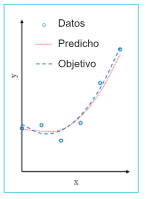

## Modelo de Regresion Simple 
un modelo de regresion sirve para predecir una variable en funcion de otra 

## Ejemplo

In [25]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

from sklearn.linear_model import LinearRegression

In [28]:
## cargamos con el data frame a trabajar 
df = pd.read_csv('data_galton.csv',header='infer')
df.head()

,child,parent
0,61.7,70.5
1,61.7,68.5
2,61.7,65.5
3,61.7,64.5
4,61.7,64.0


In [ ]:
table = pd.crosstab(df.parent,df.child)  # Creamos una tabla cruzada 
table
''' Nota -> la tabla cruzada nos ayuda a ver la relacion entre las 
variables(cuantas veces apearece la combinacion)
en otras palabras se construye una tabla de frecuencias conjuntas que nos 
permite ver  
* Patrones de relacion
*Distribucion conjunta'''

child,61.7,62.2,63.2,64.2,65.2,66.2,67.2,68.2,69.2,70.2,71.2,72.2,73.2,73.7
parent,,,,,,,,,,,,,,
64.0,1,0,2,4,1,2,2,1,1,0,0,0,0,0
64.5,1,1,4,4,1,5,5,0,2,0,0,0,0,0
65.5,1,0,9,5,7,11,11,7,7,5,2,1,0,0
66.5,0,3,3,5,2,17,17,14,13,4,0,0,0,0
67.5,0,3,5,14,15,36,38,28,38,19,11,4,0,0
68.5,1,0,7,11,16,25,31,34,48,21,18,4,3,0
69.5,0,0,1,16,4,17,27,20,33,25,20,11,4,5
70.5,1,0,1,0,1,1,3,12,18,14,7,4,3,3
71.5,0,0,0,0,1,3,4,3,5,10,4,9,2,2


In [33]:
nrows = table.shape[0]  # Guradamos el numero de filas 
ncolumns = table.shape[1]     # Guardamos el numero de columnas 

childHeight = list(table.columns)  #Guardamos la altura de los niños en una lista 
parentHeight = list(table.index)   #Guardamos la altura de los padres en un lista

# Creamos una lista de trios (parentHeight,childGeight,frecuencia)
Combo = [(x,y,table.loc[x,y])
        for x in parentHeight
        for y in childHeight ]

Combo = pd.DataFrame(Combo,columns=['X','Y','Freq'])  # creamos un Datafrema apartir de la lista 
Combo


,X,Y,Freq
0,64.0,61.7,1
1,64.0,62.2,0
2,64.0,63.2,2
3,64.0,64.2,4
4,64.0,65.2,1
...,...,...,...
149,73.0,70.2,0
150,73.0,71.2,0
151,73.0,72.2,1
152,73.0,73.2,3


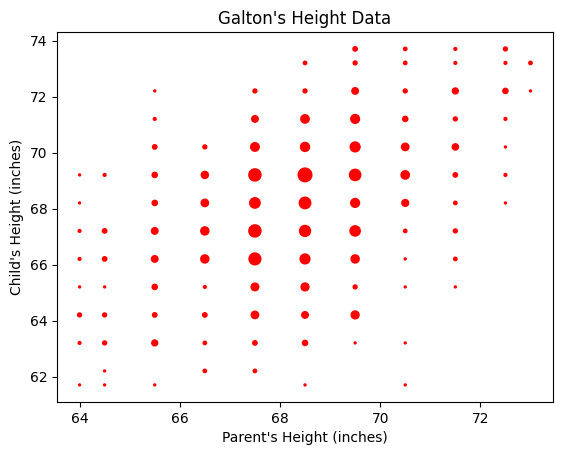

In [42]:
## Greficamos los datos 
plt.scatter(Combo.X,Combo.Y, s=Combo.Freq*2, c='red',alpha=1)
##scatter -> grafico de dispercion, 's'-> tamaño de los puntos 
plt.xlabel("Parent's Height (inches)")
plt.ylabel("Child's Height (inches)")
plt.title("Galton's Height Data")
plt.show()

In [45]:
## El modelo se centra en como la altura del padre predice la altura del hijo (modelado)
regresecion = LinearRegression(fit_intercept=True)
''' el modelo calcula el intercepto 
si fuera fit_intercept=False el modelo forzaria a la recta a 
pasar por el origen 
'''
regresecion.fit(df[['parent']], df[['child']])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
print(regresecion.intercept_,regresecion.coef_)
'''
intercept -> valor de Y cuando X=0(interseccion con el eje y)
coef -> es la pendiente de la recta,nos indica 
cuanto cambia Y cuanto cambia X aumenta 1 unidad 
'''

[23.94153018] [[0.64629058]]


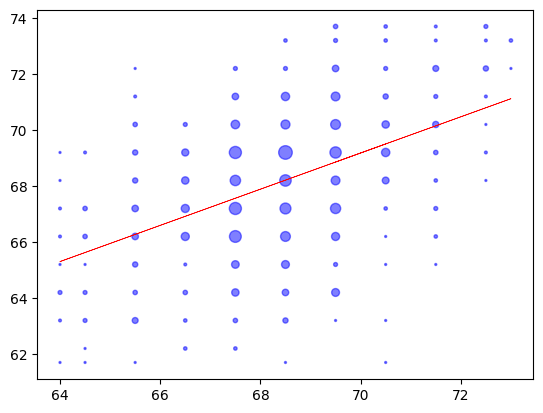

In [54]:
PredY = regresecion.predict(df[['parent']]) #El modelo usa la ecuacion estimada y=mx+b para cada valor
                                            #de parent y asi calcular una altura estimada del hijo

plt.plot(df.parent.values,PredY, c='red',linestyle='-',linewidth=0.5)     ##Dibujamos la recta 
plt.scatter(Combo.X,Combo.Y,s=Combo.Freq*2,c='blue',alpha=0.5)

## Conceptos basicos de Regresion Lineal 
Aprendizaje supervisado numerico 

- Acerca de la regresion lineal <br>
puede haber mas de una variable explicativa $x_1, x_2,... ,x_n$<br>
Hay una variable de respuesta $Y$ <br>
las variables $X_i$ e $Y$ estan conectadas por una relacion lineal<br>
$Y =\beta_0+\beta_1x_1+\beta_2x_2+...+\beta_nx_n+$ $\varepsilon$ <br> $\beta_n$ -> se denominan coeficientes de regresion. los cuales se consideran parametros del modelo <br>
$\varepsilon$ -> se denomina error el cual debe de tener media cero y varianza cte  

- Proposito de la regresion lineal 
1. indica que variables explicativas tienen mayor impacto en la variable de respuesta 
2. Predice la respuesta dadas las condiciones de las variables explicativas 

- Suposiciones 
1. la variable de respuesta se puede explicar mediante una  combinacion lineal de las variables explicativas $x$ 

2. No debe haber multicolinealidad (ocurre cuando dos o mas variables independientes estan fueretemente correlacionadas entre si en un modelo de regresion)

3. Normalidad en los residuos: los errores deben distribuirse normalmente alrededor de 0

4. Varainza cosntante(Homoscedaticidad): la varianza de los errores debe ser cte para todos los valores de $x$. Esto significa que la dispercion vertical de los puntos alrededor de la recta debe ser similar en todo el rango 

5. Indepencia / Aleatoriedad de los residuos:
estos __No__ deben de mostrar patrones como tendencias,forma curva,estructura  <br>
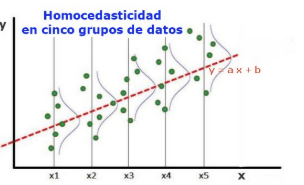


## Entramiento y Prediccion de regresion(pruebas)

1. Paso de entrenamiento: se usa el conjunto de datos de entrenamieto y obtenga un conjunto de parametros del modelo $\beta$<br>
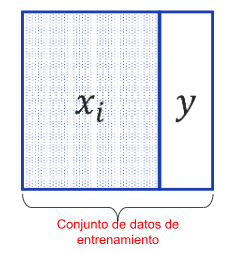

2. Prediccion: dado un nuevo conjunto de datos $x_i$, calcule el valor de $y$ el cual era desconocido 
dado los valores $x_1,x_2,...,x_n$, calcular <br> $Y =\beta+\beta_1x_1+\beta_2x_2+...+\beta_nx_n+$ $\varepsilon$ 

## Papel de las variables categoricas 
permiten 
1. Medir diferencias entre grupos 
2. Evaluar si pertenece a una categoria cambiando el valor esperado de la variable dependiente <br>

- transformandolo en una variable dummy (0 y 1)

# Diagnostico de regresion lineal 

 metricas de error:
- Error cuadratico medio MSE: este tipo de metrica penaliza mucho mas los errores grandes <br>
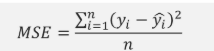

- RMSE: regresa a las unidades originales ya que es la raiz cuadrada del MSE

- Error absoluto medio:este tipo de matrica es mas robusto a valores atipicos(outliers)<br>
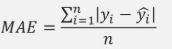

- Error absoluto porcentual medio:<br>
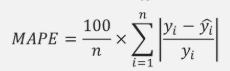

- Coeficiente de determinacion(R^2): es una metrica que mide que proporcion de la variabilidad de la variable dependiente es explicadad por el modelo<br> 
 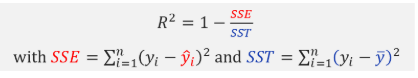
1. esta metrica es acotado por arriba y por abajo  0 < R < 1
2. cercana a uno significa que la variable de respuesta esta bien explicada 

- La prueba F: Sirve para evaluar si el modelo completo es estadisticamente significativo, en otras palabras. El conjunto de variables explicativas realmente aporta informacion ?

- Prueba t : nos ayuda a evaluar si una variable especifica tiene un efecto estadisticamente significativo sobrre la variable dependiente <br>
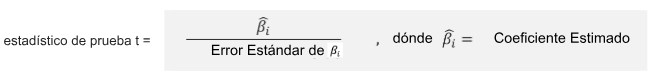



# Analisis residual 
Razones para el analisis residual 
1. nos ayuda para detectar valores atipicos en Y 
2. se verifica de mejor manera los supuestos de la regresion lineal 
Hay que tener en cuenta lo siguiente 
- Los residuos deben distribuirse normalmente centrados al rededor de 0  
- Los residuos deben distribuirse con una varinza constante 
- los residuos deben distribuirse al azar sin un patron 